<a href="https://colab.research.google.com/github/brenrcarcao-dot/analysis-ladb_mobility_economy_2024/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean().sort_values(ascending=False))# Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
En el dataset de **users** las columnas con valores faltantes son: 1. city con una proporción del 11.72% y 2.churn_date con una proporción del 88.35%. Mientras que en el dataset de **usage** las columnas con valores faltantes fueron: 1. duration con una proporción del 55.19%, 2. length con una proporción del 44.74% y 3. date con una proporción del 0.12%

- Indica qué harías: ¿imputar, eliminar, ignorar?
  
**Dataset users**:  - city, se investigará si existe algún patrón asociado a otras variables; mientras no exista una regla confiable para recuperar la ciudad, los valores se mantendrán como nulos para evitar introducir información artificial. -churn_date, aunque la proporción es muy alta, los valores nulos son esperados si corresponden a usuarios que continúan activos. Por ello, no se imputarán ni eliminarán, ya que la ausencia de una fecha de churn contiene información relevante sobre el estado del cliente.

**Dataset usage**:  - date la ausencia aquí es mínima, pero la fecha es necesaria para realizar análisis temporales y no existe una regla confiable para imputarla por lo que se conservarán los nulos. -duration y -lenght se verificará si los nulos corresponden a registros de mensajes (duration) y llamadas (lenght) dependiendo el caso. Si es así, se considerarán nulos estructurales, ya que la duración solo aplica a llamadas, y se mantendrán como NaN sin imputación.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
numericas_users = ['user_id','age']
users[numericas_users].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` el count coincide con el número total de filas, lo que significa que no hay valores ausentes.
- La columna `age` detectamos un sentinel en el valor mínimo con -999 que está afectando el resto de los datos desde el promedio, hasta los percentiles.

In [ ]:
# explorar columnas numéricas de usage
numericas_usage = ['id','user_id','duration','length']
usage[numericas_usage].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`nos muestran que no existen valores nulos debido a que su count coincide con el número de filas.
- Las columnas `duration` y `length` Hay valores ausentes que son esperados siempre y cuando coincidan los valores ausentes en llamada/length y texto/duration, Hay valores atípicos máximos para ambos casos ya que la mediana y el promedio son muchísimo menores que el max. Y también hay usuarios que no hacen uso de su plan tanto para llamadas como para mensajes.

In [ ]:
# explorar columnas categóricas de users

print(users['city'].value_counts())
print(users['plan'].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` nos muestra 96 strings (?) por lo que contamos con un total de 565 valores desconocidos para esta columna, lo que ahora nos representa el 14.12%
- La columna `plan` no tiene ningun valor faltante ya que la suma de ambos planes básico y premium suman el número total de filas

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no tiene valores faltantes, ya que la suma de mensajes de texto (22092) y llamadas (17908) es igual a 40000, que corresponde al total de filas del dataset.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? Se encontraron sentinels en la columna edad y encontramos valores inválidos en la columna city del dataset de users.
- ¿Qué acción tomarías?  Para los sentinels de edad, se imputarían con la mediana y para la ciudad vamos a remplazar los sentinels con NA para identificarlos como nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, encontramos 40 valores imposibles correspondientes al año 2026 ya que sabemos que los datos están registrados hasta el año 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, no hay fechas imposibles y únicamente contamos con datos del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Sí, para el dataset de users en la columna reg_date encontramos 40 valores imposibles corresponidente a una fecha futura para el momento de la captura de datos.
- ¿Qué harías con ellas? Lo que haremos con esos 40 valores será nulificarlos (NA)

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:


# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users.loc[users['city'] == '?', 'city'] = np.nan

# Verificar cambios
print(users['city'].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage['duration'].isna()]['type'].value_counts(dropna=False))



text    22076
Name: type, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage['length'].isna()]['type'].value_counts(dropna=False))

call    17896
Name: type, dtype: int64


Los valores faltantes de `duration` y `length` dependen de la variable type: los nulos de `duration` corresponden a mensajes (text), mientras que los nulos de `length` corresponden a llamadas (call). Por lo tanto, se consideran valores faltantes MAR y se conservarán como nulos sin imputación, ya que representan campos que no aplican según el tipo de uso.

In [ ]:
print(usage['date'].isna().sum())

50


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
  
3. Combina esta tabla con `users`

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile = user_profile.fillna({'cant_mensajes':0,'cant_llamadas':0,'cant_minutos_llamada':0})
numericas_user_profile = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[numericas_user_profile].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.122250,5.523000,4.477000,23.311225
std,17.690408,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True)*100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

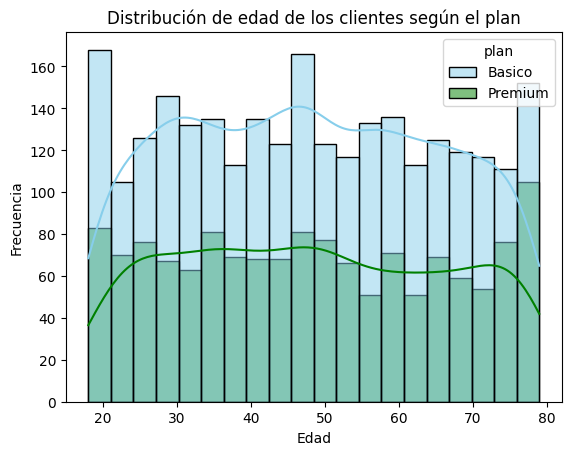

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data =user_profile,
             x='age',
             hue='plan',
             bins=20,
             palette=['skyblue','green'],
             kde=True
            )
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de edad de los clientes según el plan')
plt.show()

💡Insights:
- La distribución de los usuarios de los planes Básico y Premium presenta una edad similar, no se observa un patrón claro que relacione la edad con el tipo de plan contratado. Los usuarios Básico son más frecuentes entre todas las edades y la distribución de edad es aproximadamente uniforme y no presenta un sesgo claro hacia la derecha o hacia la izquierda.

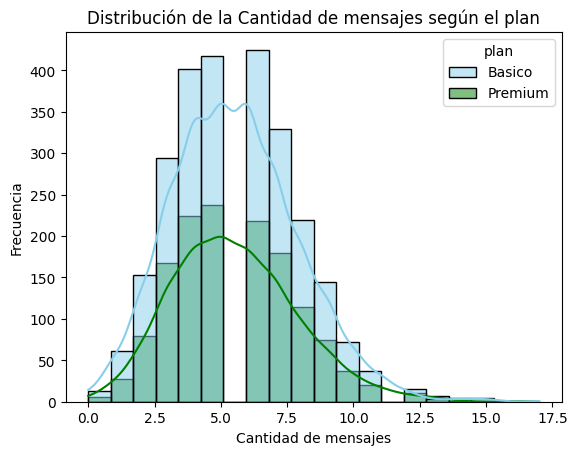

In [ ]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,
             x='cant_mensajes',
             hue='plan',
             bins=20,
             palette=['skyblue','green'],
             kde=True
            )
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Cantidad de mensajes según el plan')
plt.show()


💡Insights:
- La cantidad de mensajes presenta una distribución ligeramente sesgada a la derecha en ambos planes. La mayoría de los usuarios se concentra aproximadamente entre 3 y 8 mensajes, mientras que pocos usuarios registran cantidades considerablemente mayores. No se observan diferencias claras en el patrón de uso entre los planes Básico y Premium.

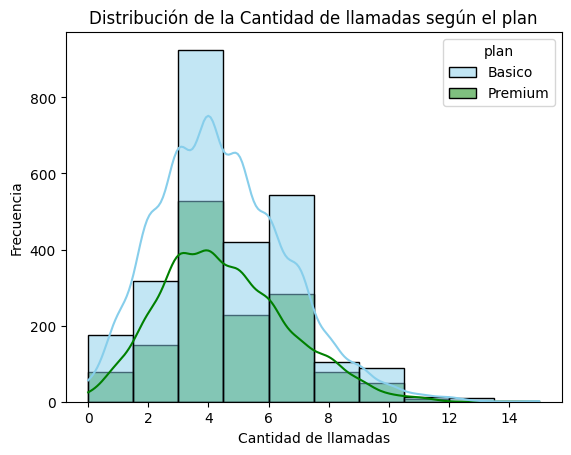

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,
             x='cant_llamadas',
             hue='plan',
             bins=10,
             palette=['skyblue','green'],
             kde=True
            )
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Cantidad de llamadas según el plan')
plt.show()

💡Insights:
- La cantidad de llamadas presenta una distribución sesgada a la derecha en ambos planes. La mayoría de los usuarios realiza aproximadamente entre 2 y 7 llamadas, mientras que pocos usuarios registran cantidades considerablemente mayores. Los planes Básico y Premium presentan patrones similares, sin observarse una diferencia clara en el comportamiento de llamadas según el plan.

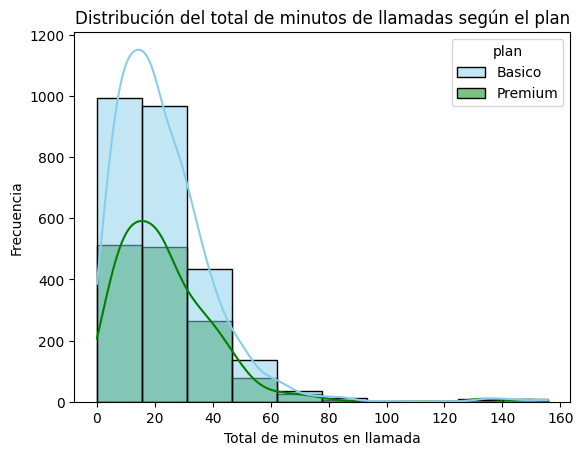

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,
             x='cant_minutos_llamada',
             hue='plan',
             bins=10,
             palette=['skyblue','green'],
             kde=True
            )
plt.xlabel('Total de minutos en llamada')
plt.ylabel('Frecuencia')
plt.title('Distribución del total de minutos de llamadas según el plan')
plt.show()

💡Insights:
- El total de minutos de llamada presenta una distribución sesgada a la derecha en ambos planes. La mayoría de los usuarios acumula entre 0 y 40 minutos, mientras que pocos usuarios registran valores considerablemente mayores, incluso superiores a 100 minutos. Los planes Básico y Premium presentan patrones de uso similares, sin observarse una diferencia clara en los minutos de llamada según el plan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

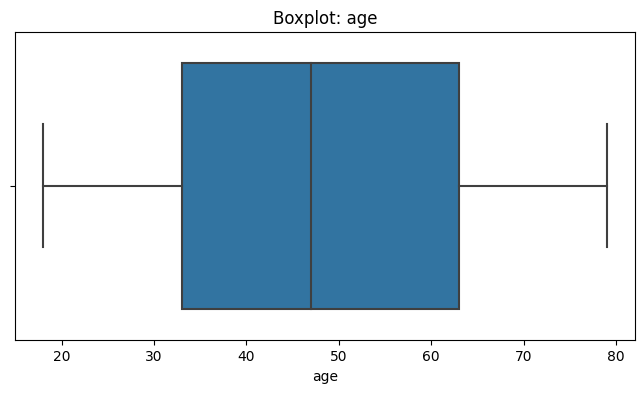

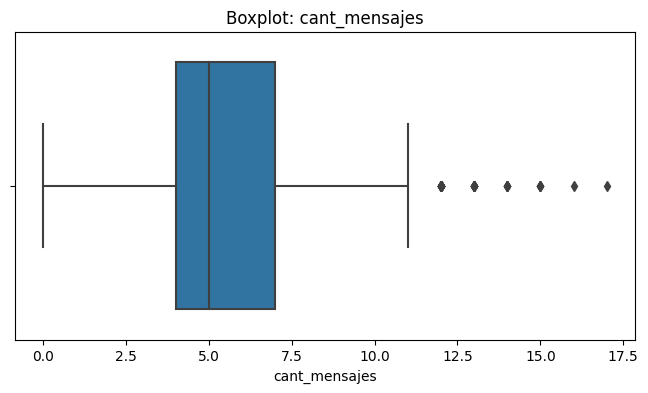

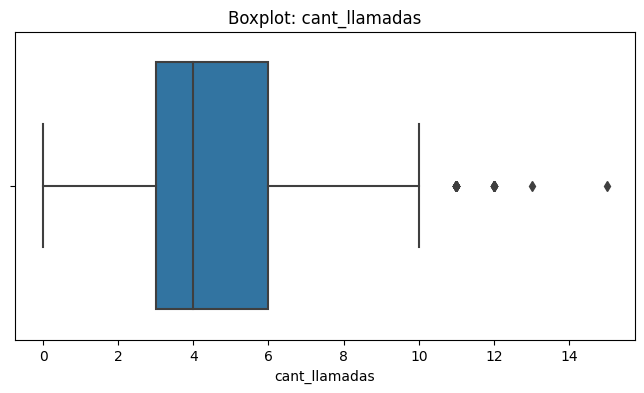

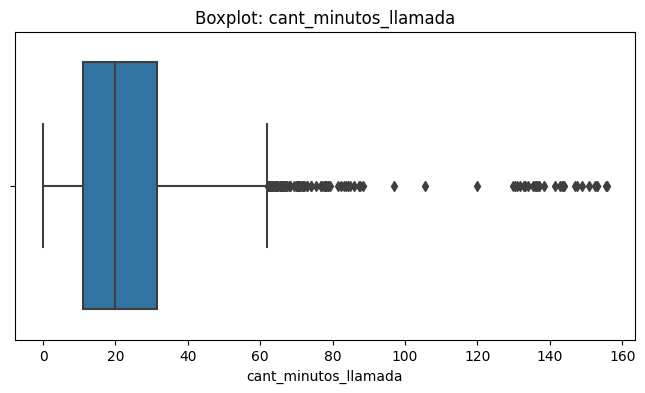

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: No presenta valores atípicos. Las edades de los clientes se encuentran dentro de los límites inferiro y superior del boxplot.
- cant_mensajes: Presenta valores atípicos únicamente por encima del del límite superior, aproximadamente a partir de 12 mensajes. Esto indica que existe un grupo pequeño de usuarios que envía considerablemente más mensajes que el comportamiento habitual.
- cant_llamadas: Presenta valores atípicos únicamente por encima del límite superior, aproximadamente a partir de 11 llamadas. Estos corresponden a usuarios con una cantidad de llamadas superior al comportamiento habitual.
- cant_minutos_llamada: Presenta numerosos valores atípicos por encima del límite superior, aproximadamente a partir de 60 minutos. Algunos usuarios incluso superan los 120 minutos, lo que indica una fuerte variabilidad en el uso de llamadas y confirma el sesgo hacia la derecha observado anteriormente.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}:')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print()

cant_mensajes:
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

cant_llamadas:
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

cant_minutos_llamada:
Q1: 11.1075
Q3: 31.4125
IQR: 20.305
Límite superior: 61.870000000000005



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Se consideran outliers los valores superiores a 11.5 mensajes. Se recomienda mantenerlos, ya que representan usuarios con un nivel de uso superior al habitual, pero los valores observados son plausibles y pueden aportar información relevante sobre clientes de alto consumo.
- cant_llamadas: Se consideran outliers los valores superiores a 10.5 llamadas. Se recomienda mantenerlos, ya que no parecen errores de registro, sino usuarios con una frecuencia de llamadas mayor al comportamiento típico, lo cual puede ser relevante para identificar diferentes perfiles de consumo.
- cant_minutos_llamada: Se consideran outliers los valores superiores a 61.87 minutos. Aunque existen casos considerablemente elevados, con un máximo de 155.69 minutos, se recomienda mantenerlos porque son valores posibles y pueden representar usuarios de alto consumo que resultan relevantes para el análisis comercial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

# Definir condiciones
condicion_bajo = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
condicion_medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)

# Definir listas de condiciones y resultados
condiciones = [
    condicion_bajo,
    condicion_medio
]

resultados = [
    'Bajo uso',
    'Uso medio'
]

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(
    condiciones,
    resultados,
    default='Alto uso'
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Definir condiciones
condicion_joven = (user_profile['age'] < 30)
condicion_adulto = (user_profile['age'] < 60)

# Definir listas de condiciones y resultados
condiciones = [
    condicion_joven,
    condicion_adulto
]

resultados = [
    'Joven',
    'Adulto'
]

# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    condiciones,
    resultados,
    default='Adulto Mayor'
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

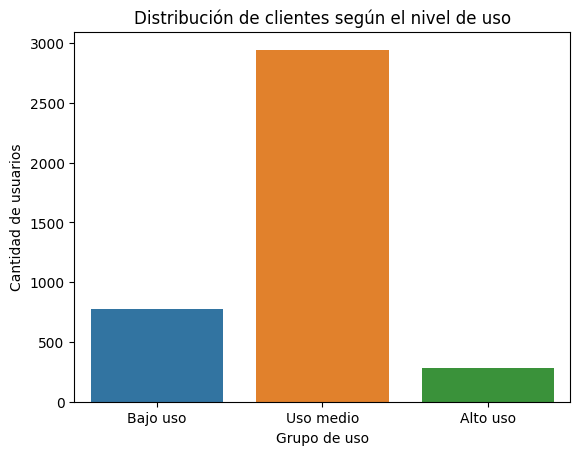

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de clientes según el nivel de uso')

plt.show()

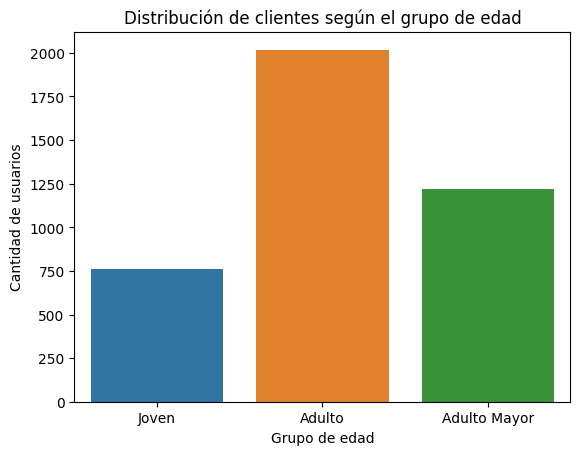

In [ ]:

# Visualización de los segmentos por edad


sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven','Adulto','Adulto Mayor']
)

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de clientes según el grupo de edad')

plt.show()


In [ ]:
tabla_edad_uso = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso']
)

tabla_edad_uso

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,153,365,1500
Adulto Mayor,74,257,891
Joven,51,157,552


In [ ]:

tabla_edad_uso_pct = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    normalize='index'
) * 100

tabla_edad_uso_pct


grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.581764,18.087215,74.331021
Adulto Mayor,6.055646,21.031097,72.913257
Joven,6.710526,20.657895,72.631579



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En users, city presentó 469 valores faltantes y 96 registros con el sentinel "?". Después de convertir estos valores inválidos a nulos, se obtuvieron 565 ciudades desconocidas (14.12%). Se conservaron como nulos debido a que no existe información suficiente para determinar correctamente la ciudad de estos usuarios.
- En age se identificaron valores sentinel de -999, correspondientes a edades inválidas. Estos valores fueron reemplazados por la mediana de edad, evitando perder registros y utilizar valores extremos incorrectos en los análisis posteriores.
- En las variables de fecha se detectaron dos problemas. En usage, date presentó 50 valores faltantes (0.125%). Estos registros se conservaron porque, aunque no sabemos en qué fecha ocurrió la actividad, sí contamos con información válida sobre las llamadas o mensajes realizados por esos usuarios, que es lo que necesitamos para este análisis. Por otro lado, en users se identificaron 40 fechas de registro (reg_date) correspondientes a 2026, lo cual no es consistente con el periodo del dataset, que contiene información hasta 2024. Por esta razón, estas fechas se reemplazaron por valores nulos para evitar trabajar con información incorrecta.
- churn_date presentó 3,534 valores faltantes (88.35%). Sin embargo, estos valores corresponden a usuarios que continúan activos, por lo que se conservaron como nulos, ya que su ausencia contiene información relevante sobre el estado del cliente.
- En usage, duration presentó 22,076 valores faltantes (55.19%) y length 17,896 (44.74%). Se comprobó que estos valores dependen de type: duration es nulo en los mensajes y length en las llamadas. Por esta razón se conservaron sin imputación, ya que representan campos que no aplican según el tipo de actividad.


🔍 **Segmentos por Edad**
- La base de clientes está compuesta principalmente por Adultos, seguidos por Adultos Mayores, mientras que los Jóvenes representan el segmento menos numeroso.
- Al cruzar edad con nivel de uso, se encontró un comportamiento muy similar entre los tres segmentos. El Uso medio representa aproximadamente 73–74% de los clientes de cada grupo de edad; el Bajo uso, entre 18–21%; y el Alto uso, entre 6–8%.
- Por ejemplo, el 21.03% de los Adultos Mayores presenta Bajo uso, aproximadamente 1 de cada 5. Sin embargo, esta proporción es similar a la de Jóvenes (20.66%) y Adultos (18.09%), por lo que el bajo consumo no parece ser exclusivo de un grupo de edad.

➡️ Esto sugiere que la edad por sí sola no es un factor suficiente para diferenciar las necesidades de consumo de los clientes. La segmentación comercial debería considerar principalmente su comportamiento real de uso y no únicamente su grupo de edad.


📊 **Segmentos por Nivel de Uso**
- El segmento predominante es Uso medio, con cerca de tres cuartas partes de los clientes. El Bajo uso representa aproximadamente una quinta parte de la base, mientras que el Alto uso constituye el grupo más pequeño.
- Se identificaron valores atípicos superiores a 11.5 mensajes, 10.5 llamadas y 61.87 minutos de llamada mediante el método IQR. Estos valores se conservaron porque son consumos plausibles y pueden representar usuarios con necesidades superiores a las del cliente habitual, en lugar de errores de registro.
- Aunque el segmento de Alto uso es pequeño, resulta especialmente relevante desde una perspectiva comercial debido a sus mayores necesidades de consumo. Sin embargo, con los datos disponibles no es posible afirmar que estos clientes sean necesariamente los más rentables.
- Los histogramas por plan mostraron patrones similares de mensajes, llamadas y minutos entre Básico y Premium, sin una diferenciación clara en el comportamiento de consumo. Esto plantea la oportunidad de revisar si los planes actuales están suficientemente alineados con los distintos niveles de uso identificados.


➡️ Esto sugiere que el nivel de uso puede ser una variable más útil que el tipo de plan actual para identificar distintas necesidades entre los clientes. Aunque la mayoría presenta un consumo medio, existen grupos de bajo y alto uso con comportamientos diferentes que podrían no estar siendo atendidos de forma específica por los planes Básico y Premium.


💡 **Recomendaciones**
- Priorizar el comportamiento de uso sobre la edad para la segmentación comercial, ya que los distintos grupos de edad presentan proporciones muy similares de Bajo, Medio y Alto uso.
- Mantener una oferta principal orientada al segmento de Uso medio, debido a que representa la mayor parte de la base de clientes y, por tanto, el comportamiento típico de consumo.
- Evaluar una oferta específica para clientes de Alto uso, con mayores beneficios de llamadas, mensajes o minutos incluidos. Los usuarios identificados como outliers podrían analizarse como posibles candidatos para este tipo de plan o para estrategias de migración hacia productos de mayor capacidad.
- Evaluar alternativas para clientes de Bajo uso, como planes de menor capacidad o precio, con el objetivo de ofrecer una propuesta más ajustada a sus necesidades y reducir el riesgo de que paguen por beneficios que utilizan poco.
- Revisar la diferenciación entre los planes Básico y Premium, ya que los patrones de consumo observados son similares. Un análisis posterior de consumo frente a precio, beneficios incluidos y rentabilidad permitiría determinar si la estructura actual de planes responde adecuadamente a las necesidades reales de los clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`